# Movie dRSA with dense optical-flow vectors

This notebook compares time-resolved movie neural representations with dense Farneback
optical flow extracted by `run_optical_flow_extraction.py`.

Each movie frame is represented by a flattened dense flow field:

```text
[all horizontal displacements u, all vertical displacements v]
```

The flow at retained frame `t` describes displacement from retained frame `t-1` to `t`.
During extraction, near-zero flow runs caused by duplicated/upsampled frames are linearly
interpolated when they are bounded by healthy flow fields on both sides. Unbounded
leading/trailing runs are left unchanged because two interpolation endpoints do not exist.

The first frame always has an all-zero vector because no preceding frame exists. This
notebook drops that vector before RDM construction and retains the resulting one-frame
model-time offset explicitly.

## 1. Imports and project setup

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import squareform


ENV = os.getenv("MY_ENV", "tiziano_mac_mini")


"""
find_project_root
Finds the nearest parent directory containing config.yaml.

INPUT:
    - start_path: str | Path -> directory where the upward search starts

OUTPUT:
    - project_root: Path -> project directory containing config.yaml
"""
def find_project_root(start_path=Path.cwd()):
    start_path = Path(start_path).resolve()
    for candidate in (start_path, *start_path.parents):
        if (candidate / "config.yaml").exists():
            return candidate
        # end if config.yaml exists
    # end for candidate
    raise FileNotFoundError(f"Could not find config.yaml above {start_path}")
# EOF


PROJECT_ROOT = find_project_root()
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]

for src_path in (paths["src_path"], paths["useful_stuff_path"]):
    if src_path not in sys.path:
        sys.path.append(src_path)
    # end if src_path
# end for src_path

from image_processing.optical_flow import load_aligned_optical_flow_features
from image_processing.video_feature_extraction import (
    match_feature_stimulus_names,
)
from project_specific_utils import (
    load_natraster,
    min_max_normalization,
    select_stimulus_rasters,
)
from useful_stuff.general_utils import (
    TimeSeries,
    get_lagplot_subset,
)
from useful_stuff.general_utils.RSA import dRSA

print(f"Environment: {ENV}")
print(f"Project root: {PROJECT_ROOT}")

Environment: tiziano_mac_mini
Project root: /Users/tizianocausin/Desktop/static_dynamic


## 2. Configuration

Run the extractor before this notebook:

```bash
MY_ENV=tiziano_mac_mini .venv/bin/python       python_scripts/scripts/run_optical_flow_extraction.py
```

Internal zero-flow interpolation is enabled by default with an RMS displacement threshold
of `0.05` flow-grid pixels. Rerunning the command repairs existing raw HDF5 movie datasets in place; it does
not require recomputing Farneback flow. Use `--no-interpolate-zero-flow` only when explicitly
requesting raw zero-flow plateaus.

The default extraction produces a 64×64×2 field (8192 features) at every movie frame.

In [18]:
@dataclass
class Cfg:
    exp_name: str = "red_20260720to24" #"baby1_260716to24" #

    # MATLAB channels 84--186 inclusive; Python stop indices are exclusive.
    good_channels: tuple[int, int] | None = None #(101,109) #(84, 186)
    # Optional response-based selection, e.g. top_k=10 for the other monkey.
    top_k: int | None = 10
    video_crop_ms: int | None = None
    new_fs: float = 100
    normalization: str | None = None  # None or "min_max"

    flow_feature_path: str | Path | None = None
    drop_first_flow_frame: bool = True

    signal_RDM_metric: str = "cosine_cnt"
    model_RDM_metric: str = "correlation"
    RSA_metric: str = "correlation"

    lag_analysis_end_ms: float = 2500
    max_lag_ms: float = 700
    aligned_curve_smoothing_sigma: float = 2

    example_movie_index: int = 0
    example_flow_frame_index: int = 20
    quiver_stride: int = 4
# EOF


cfg = Cfg()
natraster_path = (
    Path(paths["data_path"]) / "data" / f"{cfg.exp_name}_natraster_vid.mat"
)
flow_feature_path = Path(
    cfg.flow_feature_path
    or Path(paths["data_path"])
    / "models"
    / "optical_flow_farneback_static_dynamic.h5"
).expanduser()

print(cfg)
print(f"Neural data: {natraster_path}")
print(f"Optical flow: {flow_feature_path}")

Cfg(exp_name='red_20260720to24', good_channels=None, top_k=10, video_crop_ms=None, new_fs=100, normalization=None, flow_feature_path=None, drop_first_flow_frame=True, signal_RDM_metric='cosine_cnt', model_RDM_metric='correlation', RSA_metric='correlation', lag_analysis_end_ms=2500, max_lag_ms=700, aligned_curve_smoothing_sigma=2, example_movie_index=0, example_flow_frame_index=20, quiver_stride=4)
Neural data: /Users/tizianocausin/sd_local/data/red_20260720to24_natraster.mat
Optical flow: /Users/tizianocausin/sd_local/models/optical_flow_farneback_static_dynamic.h5


## 3. Load movie neural responses

The movie conditions remain in MATLAB `uniqueImage` order. Channel selections and temporal
resampling match the existing movie dRSA workflow in this project.

In [19]:
rasters, all_stimulus_names = load_natraster(natraster_path)
video_rasters, video_names = select_stimulus_rasters(
    rasters,
    all_stimulus_names,
    stimulus_prefix="vid_",
)

if cfg.good_channels is not None:
    first_channel, last_channel = cfg.good_channels
    channel_slice = slice(first_channel - 1, last_channel)
    video_rasters = video_rasters[channel_slice]
# end if cfg.good_channels

if video_rasters.shape[0] == 0:
    raise ValueError("good_channels selected zero neural channels.")
# end if no selected channels

selected_top_channel_indices = None
if cfg.top_k is not None:
    if not 1 <= cfg.top_k <= video_rasters.shape[0]:
        raise ValueError(
            f"top_k must be between 1 and {video_rasters.shape[0]}; "
            f"got {cfg.top_k}."
        )
    # end if invalid top_k

    # Rank channels by their maximum response across all movie times and stimuli.
    channel_scores = video_rasters.max(axis=(1, 2))
    selected_top_channel_indices = np.argsort(channel_scores)[
        -cfg.top_k:
    ][::-1]
    video_rasters = video_rasters[selected_top_channel_indices]
# end if cfg.top_k

if cfg.video_crop_ms is not None:
    video_rasters = video_rasters[:, :cfg.video_crop_ms]
# end if cfg.video_crop_ms

video_neural_ts = TimeSeries(video_rasters, fs=1000)
video_neural_ts.resample(cfg.new_fs)

if cfg.normalization == "min_max":
    video_neural_ts.set_array(
        min_max_normalization(video_neural_ts.get_array())
    )
elif cfg.normalization is not None:
    raise ValueError("normalization must be None or 'min_max'.")
# end if normalization

print(f"Movie conditions: {len(video_names)}")
print(
    "Neural [channels,time,stimuli]: "
    f"{video_neural_ts.shape()} at {video_neural_ts.get_fs():g} Hz"
)
if selected_top_channel_indices is not None:
    if cfg.good_channels is None:
        selected_matlab_channels = selected_top_channel_indices + 1
    else:
        selected_matlab_channels = (
            selected_top_channel_indices + cfg.good_channels[0]
        )
    # end if cfg.good_channels
    print(
        f"Top-{cfg.top_k} MATLAB channels: "
        f"{selected_matlab_channels.tolist()}"
    )
# end if selected_top_channel_indices
print("First movie names:", video_names[:5])

Movie conditions: 100
Neural [channels,time,stimuli]: (10, 350, 100) at 100 Hz
Top-10 MATLAB channels: [45, 3, 7, 57, 37, 5, 58, 31, 2, 19]
First movie names: ['vid_0_0_41171.mp4', 'vid_1500_animal_names1.mp4', 'vid_4115_11.01.mp4', 'vid_43.81_41411.mp4', 'vid_4_5_41241.mp4']


## 4. Match and load optical-flow vectors

Dataset names are matched by stimulus identity, ignoring the `vid_` prefix and file
extension differences. The loader then returns the project convention
`(features, time, stimuli)`.

The loader verifies that all selected movies use the same zero-flow policy and threshold.
This notebook requires `linear_internal_interpolation` so stale raw files cannot silently
enter the dRSA.

Dropping the first all-zero vector prevents undefined cosine distances. The first model
sample therefore occurs at `1 / effective_fps` seconds, and that offset is used in every
time-axis and lag calculation below.

In [20]:
if not flow_feature_path.exists():
    raise FileNotFoundError(
        f"{flow_feature_path} does not exist. Run "
        "python_scripts/scripts/run_optical_flow_extraction.py first."
    )
# end if not flow_feature_path.exists()

flow_movie_names = match_feature_stimulus_names(
    flow_feature_path,
    video_names,
)
flow_features, source_flow_fs, flow_metadata = (
    load_aligned_optical_flow_features(
        flow_feature_path,
        flow_movie_names,
        drop_first_frame=cfg.drop_first_flow_frame,
    )
)

expected_zero_flow_policy = "linear_internal_interpolation"
if flow_metadata["zero_flow_policy"] != expected_zero_flow_policy:
    raise RuntimeError(
        "The optical-flow file has not been repaired with internal linear "
        "interpolation. Rerun run_optical_flow_extraction.py with its "
        "default --interpolate-zero-flow setting."
    )
# end if zero_flow_policy

print("First neural-to-flow mappings:")
for neural_name, flow_name in zip(video_names[:5], flow_movie_names[:5]):
    print(f"  {neural_name} -> {flow_name}")
# end for names
print(
    f"Flow [features,time,stimuli]: {flow_features.shape} "
    f"at {source_flow_fs:g} Hz"
)
print(
    "Zero-flow repair: "
    f"policy={flow_metadata['zero_flow_policy']}, "
    f"RMS threshold={flow_metadata['zero_flow_threshold']:g}, "
    f"frames={flow_metadata['interpolated_zero_frames_total']}, "
    f"runs={flow_metadata['interpolated_zero_runs_total']}"
)

repaired_frames_by_movie = (
    flow_metadata["interpolated_zero_frames_by_movie"]
)
most_repaired_movies = sorted(
    repaired_frames_by_movie.items(),
    key=lambda item: item[1],
    reverse=True,
)[:10]
print("Movies with the most interpolated frames:")
for movie_name, repaired_frame_count in most_repaired_movies:
    print(f"  {movie_name}: {repaired_frame_count}")
# end for movie_name

# Report remaining near-zero samples after dropping the undefined first frame.
# These can be legitimate stillness or unbounded edge runs; bounded plateaus
# have already been repaired in the extraction file.
flow_rms = np.sqrt(
    np.mean(flow_features.astype(np.float64) ** 2, axis=0)
)
remaining_near_zero = (
    flow_rms <= flow_metadata["zero_flow_threshold"]
)
print(
    "Remaining near-zero flow samples after first-frame removal: "
    f"{remaining_near_zero.sum()} / {remaining_near_zero.size}"
)

flow_ts = TimeSeries(flow_features, fs=source_flow_fs)
flow_ts.resample(video_neural_ts.get_fs())
print(
    "Resampled flow [features,time,stimuli]: "
    f"{flow_ts.shape()} at {flow_ts.get_fs():g} Hz"
)

First neural-to-flow mappings:
  vid_0_0_41171.mp4 -> vid_0_0_41171.mp4
  vid_1500_animal_names1.mp4 -> vid_1500_animal_names1.mp4
  vid_4115_11.01.mp4 -> vid_4115_11.01.mp4
  vid_43.81_41411.mp4 -> vid_43.81_41411.mp4
  vid_4_5_41241.mp4 -> vid_4_5_41241.mp4
Flow [features,time,stimuli]: (8192, 179, 100) at 60 Hz
Zero-flow repair: policy=linear_internal_interpolation, RMS threshold=0.05, frames=5368, runs=4673
Movies with the most interpolated frames:
  vid_beautiful_dancers1.mp4: 85
  vid_owl_butterfly1.mp4: 85
  vid_forest_of_golden_monkeys1.mp4: 84
  vid_going_ape1.mp4: 84
  vid_going_ape2.mp4: 84
  vid_going_ape3.mp4: 84
  vid_greatest_fights1.mp4: 84
  vid_how_500_monkeys1.mp4: 84
  vid_monkeys_n_apes1.mp4: 84
  vid_monkeys_n_apes10.mp4: 84
Remaining near-zero flow samples after first-frame removal: 3176 / 17900
Resampled flow [features,time,stimuli]: (8192, 298, 100) at 100 Hz


## 5. Inspect the optical-flow representation

Horizontal displacement `u` is positive to the right. Vertical displacement `v` is
positive downward in image coordinates. The quiver plot negates `v` only for conventional
Cartesian display; the stored vector and all dRSA calculations use the original values.

Example field [components,height,width]: (2, 64, 64)
Magnitude min/mean/max: 0.8878 / 2.4674 / 4.2066


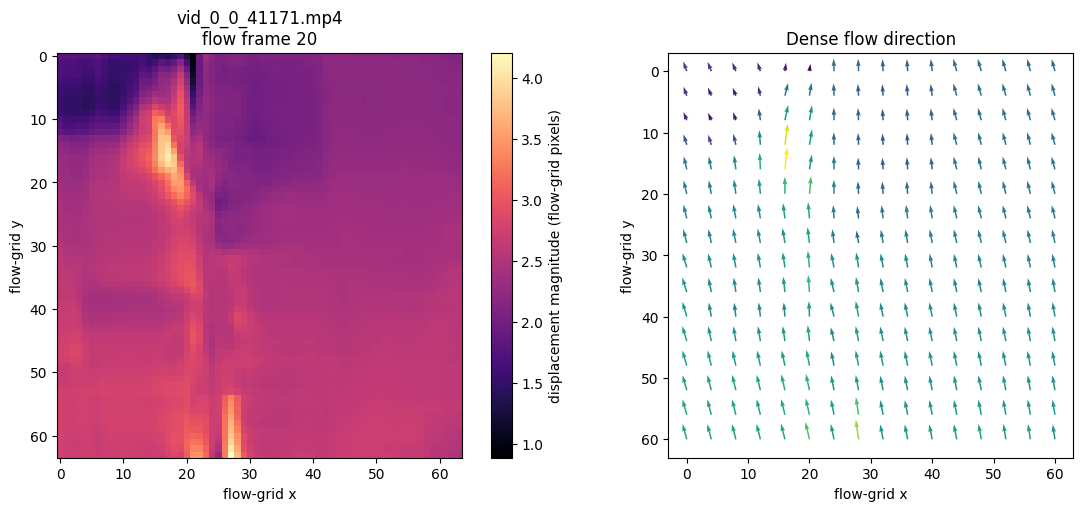

In [21]:
flow_height = flow_metadata["flow_height"]
flow_width = flow_metadata["flow_width"]
expected_features = 2 * flow_height * flow_width
if flow_features.shape[0] != expected_features:
    raise ValueError(
        f"Expected {expected_features} features from flow geometry, "
        f"got {flow_features.shape[0]}."
    )
# end if feature count
if not 0 <= cfg.example_movie_index < len(flow_movie_names):
    raise IndexError("example_movie_index is outside the movie axis.")
# end if movie index

example_frame = min(
    cfg.example_flow_frame_index,
    flow_features.shape[1] - 1,
)
example_vector = flow_features[
    :, example_frame, cfg.example_movie_index
]
example_field = example_vector.reshape(2, flow_height, flow_width)
flow_u, flow_v = example_field
flow_magnitude = np.sqrt(flow_u ** 2 + flow_v ** 2)

y_grid, x_grid = np.mgrid[:flow_height, :flow_width]
stride = cfg.quiver_stride
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
magnitude_image = axes[0].imshow(
    flow_magnitude,
    origin="upper",
    cmap="magma",
)
axes[0].set(
    title=(
        f"{flow_movie_names[cfg.example_movie_index]}\n"
        f"flow frame {example_frame}"
    ),
    xlabel="flow-grid x",
    ylabel="flow-grid y",
)
fig.colorbar(
    magnitude_image,
    ax=axes[0],
    label="displacement magnitude (flow-grid pixels)",
)

axes[1].quiver(
    x_grid[::stride, ::stride],
    y_grid[::stride, ::stride],
    flow_u[::stride, ::stride],
    -flow_v[::stride, ::stride],
    flow_magnitude[::stride, ::stride],
    cmap="viridis",
    angles="xy",
)
axes[1].set(
    title="Dense flow direction",
    xlabel="flow-grid x",
    ylabel="flow-grid y",
    aspect="equal",
)
axes[1].invert_yaxis()

print(
    f"Example field [components,height,width]: {example_field.shape}"
)
print(
    f"Magnitude min/mean/max: {flow_magnitude.min():.4f} / "
    f"{flow_magnitude.mean():.4f} / {flow_magnitude.max():.4f}"
)

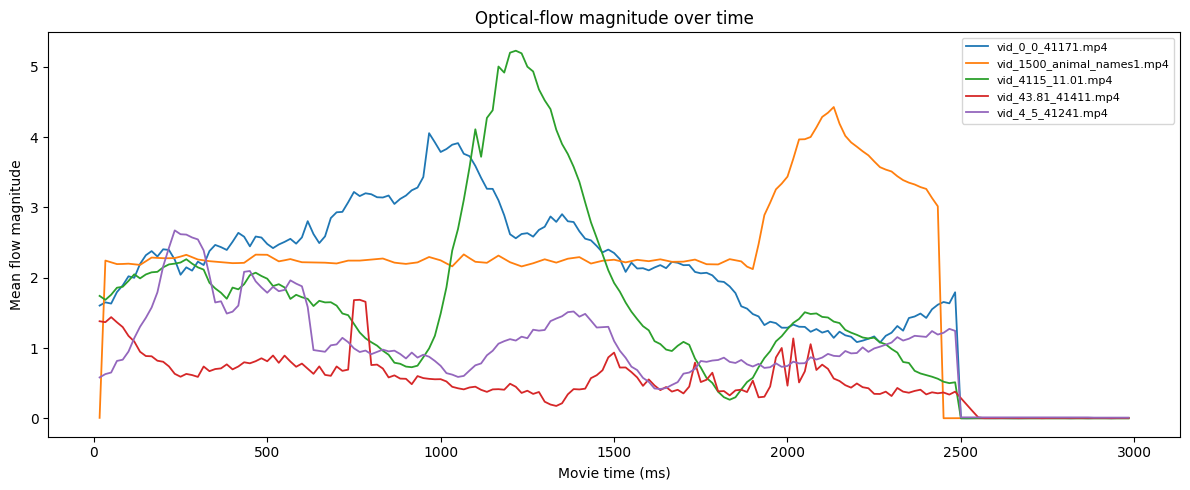

In [22]:
# Summarize motion magnitude over time for a few movies.
flow_fields = flow_features.reshape(
    2, flow_height, flow_width,
    flow_features.shape[1], flow_features.shape[2],
)
flow_magnitude_ts = np.sqrt(
    flow_fields[0] ** 2 + flow_fields[1] ** 2
).mean(axis=(0, 1))
source_model_time_ms = (
    flow_metadata["first_valid_flow_time_s"] * 1000
    + np.arange(flow_magnitude_ts.shape[0]) * 1000 / source_flow_fs
)

fig, ax = plt.subplots(figsize=(12, 5))
for movie_index in range(min(5, flow_magnitude_ts.shape[1])):
    ax.plot(
        source_model_time_ms,
        flow_magnitude_ts[:, movie_index],
        label=flow_movie_names[movie_index],
        linewidth=1.3,
    )
# end for movie_index
ax.set(
    xlabel="Movie time (ms)",
    ylabel="Mean flow magnitude",
    title="Optical-flow magnitude over time",
)
ax.legend(fontsize=8)
fig.tight_layout()

## 6. Compute movie optical-flow dRSA

An RDM is computed across movie identities at every neural timepoint and every flow
timepoint. The resulting matrix has neural time on rows and optical-flow time on columns.

In [23]:
flow_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.RSA_metric,
)
flow_drsa.compute_RDM_timeseries(video_neural_ts, "signal")
flow_drsa.compute_RDM_timeseries(flow_ts, "model")
flow_drsa_matrix = flow_drsa.compute_dRSA()

analysis_fs = video_neural_ts.get_fs()
flow_time_offset_ms = (
    flow_metadata["first_valid_flow_time_s"] * 1000
)
neural_time_ms = (
    np.arange(flow_drsa_matrix.shape[0]) * 1000 / analysis_fs
)
model_time_ms = (
    flow_time_offset_ms
    + np.arange(flow_drsa_matrix.shape[1]) * 1000 / analysis_fs
)

print(
    "Neural RDM time series [time,RDM entries]: "
    f"{flow_drsa.signal_RDM_timeseries.get_array().shape}"
)
print(
    "Flow RDM time series [time,RDM entries]: "
    f"{flow_drsa.model_RDM_timeseries.get_array().shape}"
)
print(f"dRSA [neural time,flow time]: {flow_drsa_matrix.shape}")
print(f"First valid flow time: {flow_time_offset_ms:.3f} ms")

Neural RDM time series [time,RDM entries]: (4950, 350)
Flow RDM time series [time,RDM entries]: (4950, 298)
dRSA [neural time,flow time]: (350, 298)
First valid flow time: 16.667 ms


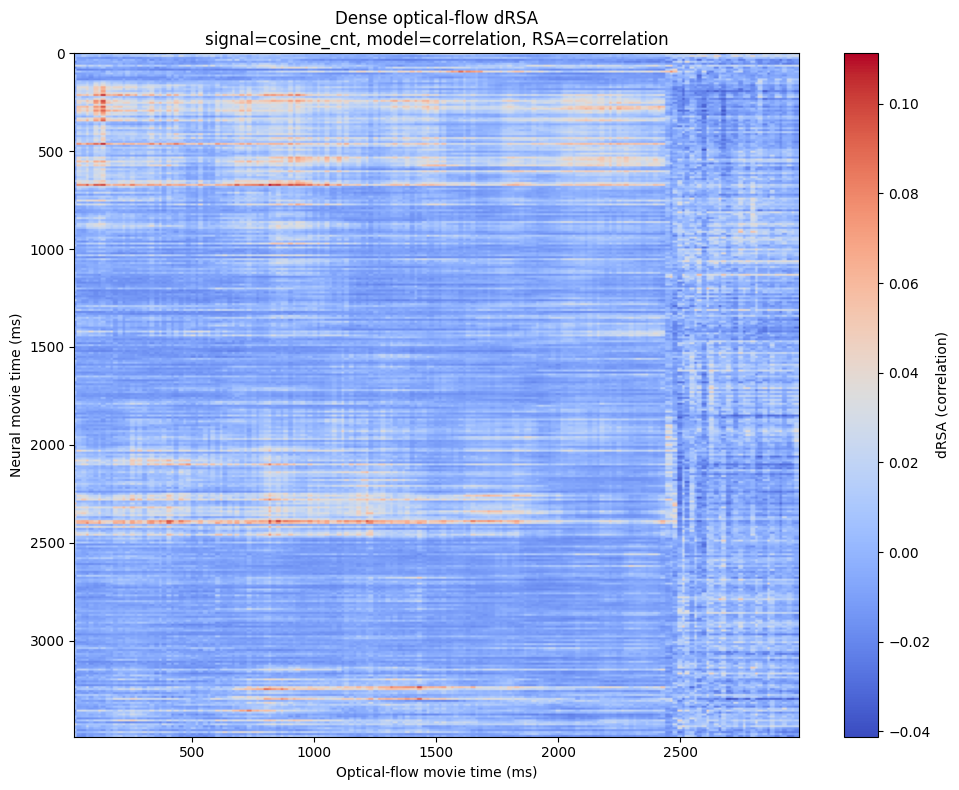

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(
    flow_drsa_matrix,
    aspect="auto",
    origin="upper",
    cmap="coolwarm",
    extent=[
        model_time_ms[0],
        model_time_ms[-1],
        neural_time_ms[-1],
        neural_time_ms[0],
    ],
)
ax.set(
    xlabel="Optical-flow movie time (ms)",
    ylabel="Neural movie time (ms)",
    title=(
        "Dense optical-flow dRSA\n"
        f"signal={cfg.signal_RDM_metric}, "
        f"model={cfg.model_RDM_metric}, RSA={cfg.RSA_metric}"
    ),
)
fig.colorbar(image, ax=ax, label=f"dRSA ({cfg.RSA_metric})")
fig.tight_layout()

## 7. Inspect example RDMs

These panels verify that both modalities compare the same movie identities in the same
order. The model panel uses the selected optical-flow frame.

In [25]:
neural_rdm_index = min(
    int(round(model_time_ms[example_frame] * analysis_fs / 1000)),
    len(flow_drsa.signal_RDM_timeseries) - 1,
)
model_rdm_index = min(
    example_frame,
    len(flow_drsa.model_RDM_timeseries) - 1,
)
neural_rdm = squareform(
    flow_drsa.signal_RDM_timeseries.get_array()[neural_rdm_index]
)
model_rdm = squareform(
    flow_drsa.model_RDM_timeseries.get_array()[model_rdm_index]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, rdm, title in (
    (
        axes[0],
        neural_rdm,
        f"Neural RDM at {neural_time_ms[neural_rdm_index]:.1f} ms",
    ),
    (
        axes[1],
        model_rdm,
        f"Flow RDM at {model_time_ms[model_rdm_index]:.1f} ms",
    ),
):
    image = ax.imshow(rdm, cmap="viridis", origin="lower")
    ax.set(xlabel="Movie", ylabel="Movie", title=title)
    fig.colorbar(image, ax=ax, label="Dissimilarity")
# end for rdm

ValueError: Incompatible vector size. It must be a binomial coefficient n choose 2 for some integer n >= 2.

## 8. Physical-time-aligned dRSA curve

Because the undefined first flow vector was removed, array index 0 corresponds to a
positive movie time. This curve samples the dRSA matrix at the nearest neural time for
every actual optical-flow time, rather than taking a naïve index diagonal.

ValueError: All-NaN slice encountered

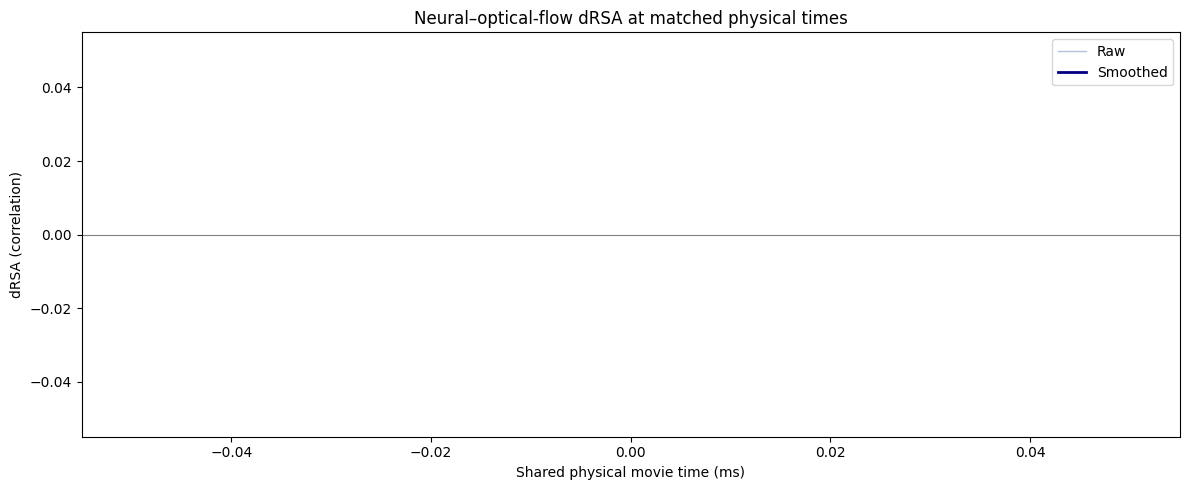

In [ ]:
valid_model_indices = np.flatnonzero(
    model_time_ms <= neural_time_ms[-1]
)
matched_neural_indices = np.rint(
    model_time_ms[valid_model_indices] * analysis_fs / 1000
).astype(int)
matched_neural_indices = np.clip(
    matched_neural_indices,
    0,
    flow_drsa_matrix.shape[0] - 1,
)
aligned_drsa = flow_drsa_matrix[
    matched_neural_indices,
    valid_model_indices,
]
aligned_drsa_smoothed = gaussian_filter1d(
    aligned_drsa,
    sigma=cfg.aligned_curve_smoothing_sigma,
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    model_time_ms[valid_model_indices],
    aligned_drsa,
    color="lightsteelblue",
    linewidth=1,
    label="Raw",
)
ax.plot(
    model_time_ms[valid_model_indices],
    aligned_drsa_smoothed,
    color="navy",
    linewidth=2,
    label="Smoothed",
)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set(
    xlabel="Shared physical movie time (ms)",
    ylabel=f"dRSA ({cfg.RSA_metric})",
    title="Neural–optical-flow dRSA at matched physical times",
)
ax.legend()
fig.tight_layout()

peak_index = int(np.nanargmax(aligned_drsa_smoothed))
print(
    f"Aligned-curve peak: {aligned_drsa_smoothed[peak_index]:.4f} "
    f"at {model_time_ms[valid_model_indices][peak_index]:.1f} ms"
)

## 9. Lag analysis with the flow-time offset

`get_lagplot_subset` works in array-sample offsets. Physical lag is:

```text
neural time - flow time
= sample lag / analysis_fs - first_valid_flow_time
```

Subtracting the model-time offset below keeps the lag axis physically meaningful.

18:26:21 - There are nans in corr_mat


/Users/tizianocausin/Desktop/useful_stuff/python_scripts/src/useful_stuff/general_utils/utils.py:250: RuntimeWarning: Mean of empty slice
  lagplot[center - tau] = stat(diag_vals)


ValueError: All-NaN slice encountered

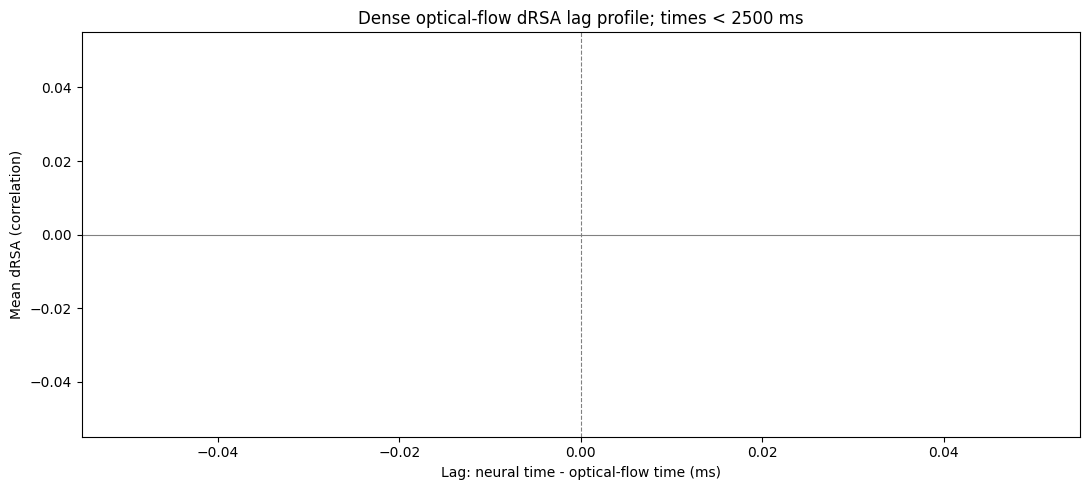

In [ ]:
neural_analysis_indices = np.flatnonzero(
    neural_time_ms < cfg.lag_analysis_end_ms
)
model_analysis_indices = np.flatnonzero(
    model_time_ms < cfg.lag_analysis_end_ms
)
max_lag_samples = min(
    int(round(cfg.max_lag_ms * analysis_fs / 1000)),
    len(neural_analysis_indices) - 1,
    len(model_analysis_indices) - 1,
)
if max_lag_samples < 1:
    raise ValueError("The lag-analysis window is too short.")
# end if max_lag_samples

flow_lagplot = get_lagplot_subset(
    flow_drsa_matrix,
    neural_idx=neural_analysis_indices,
    model_idx=model_analysis_indices,
    max_lag=max_lag_samples,
)
sample_lags = np.arange(-max_lag_samples, max_lag_samples + 1)
physical_lag_ms = (
    sample_lags * 1000 / analysis_fs - flow_time_offset_ms
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(physical_lag_ms, flow_lagplot, color="tab:purple", linewidth=2)
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set(
    xlabel="Lag: neural time - optical-flow time (ms)",
    ylabel=f"Mean dRSA ({cfg.RSA_metric})",
    title=(
        "Dense optical-flow dRSA lag profile; "
        f"times < {cfg.lag_analysis_end_ms:g} ms"
    ),
)
fig.tight_layout()

peak_lag_index = int(np.nanargmax(flow_lagplot))
print(
    f"Lag peak: {flow_lagplot[peak_lag_index]:.4f} "
    f"at {physical_lag_ms[peak_lag_index]:.1f} ms"
)

## Interpretation

- Positive lag means the neural representational geometry is later than the flow geometry.
- Negative lag means the neural geometry is earlier.
- Flow fields are measured in pixels of the resized 64×64 grid per retained-frame step.
- With `frame_stride > 1`, each vector spans more source frames and the saved
  `effective_fps` changes accordingly.
- Dense `(u,v)` vectors retain motion direction and spatial layout; no magnitude-only
  reduction is applied before dRSA.